In [ ]:
import os
import yaml
import json
from pprint import pprint
from pathlib import Path
from hydra import initialize, compose

import numpy as np

import seaborn as sns

import sys
sys.path.append('../../')
sys.path.append('../')

# sets Arial + shared rcParams; looks for arial.ttf in the working directory
from src import plot_utils as pu

In [2]:
%load_ext autoreload
%autoreload 2

# Defining folders with experiments 

In [3]:
class DotDict(dict):
    """dot.notation access to dictionary attributes"""
    __getattr__ = dict.get
    __setattr__ = dict.__setitem__
    __delattr__ = dict.__delitem__

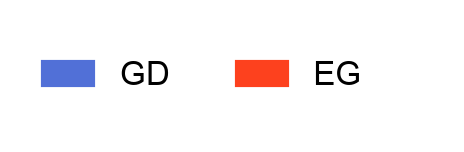

In [4]:
# Plotting setup
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches        
import matplotlib.pyplot as plt
import matplotlib as mpl

# make the legend
mlp_gd = DotDict()
mlp_eg = DotDict()


cdict = {"gd":"#5170d7", "eg":"#fd411e"}
    
mlp_gd.c = cdict['gd']
mlp_eg.c = cdict['eg']


mlp_gd.ln = "GD"
mlp_eg.ln  = "EG"

fig_1, (ax1) = plt.subplots(nrows=1, ncols=1, figsize = (1, 0.4), dpi=300, sharey=False)
ax1.axis("off")
patches = []
for exp in [mlp_gd,mlp_eg]:
    patches.append(mpatches.Patch(color=exp.c, label=exp.ln))
leg = plt.legend(handles = patches, ncol=4,
                 bbox_to_anchor=(0, 0), loc='lower center', fontsize=8, handlelength=1.5)
leg.get_frame().set_facecolor('none')
leg.get_frame().set_edgecolor('none')
# plt.savefig("figs/r_of_k_legend.pdf", bbox_inches='tight',transparent=True )
# plt.savefig("figs/r_of_k_legend.png", bbox_inches='tight',transparent=True )

In [5]:
with initialize(config_path="../conf/",version_base=None): 
    cfg = compose(config_name="main_config", overrides=["+debug=True"])
    print(cfg)

{'model': {'name': 'mlp'}, 'exp': {'use_wandb': False, 'wandb_project': 'rofk_0718', 'wandb_tag': 'rofk_0718'}, 'n_epochs': 30, 'seed': 7, 'project_results_dir': 'results', 'dataset': {'n_train_datapoints': 10000, 'n_val_datapoints': 1000, 'n_test_datapoints': 1000, 'n': 2000, 'k': 100, 'r': 50, 'batch_size': 500, 'p': 0.5}, 'opt': {'update_algorithm': 'gd', 'lr': 0.01, 'wd': 0.001, 'momentum': 0}, 'debug': True}


In [6]:
project_dir = Path("..") / cfg.project_results_dir
project_dir


PosixPath('../results')

In [7]:
task_dirs = {s.split("_")[0]: project_dir/s for s in os.listdir(project_dir) if (project_dir/s).is_dir()}
task_dirs = DotDict(task_dirs)

In [8]:
task_dirs

{'n200': PosixPath('../results/n200_k100'),
 'n20000': PosixPath('../results/n20000_k100'),
 'n2000': PosixPath('../results/n2000_k100')}

In [9]:
key = "n200"

In [10]:
print(len(os.listdir(task_dirs[key])))
os.listdir(task_dirs[key])[:10]

10


['mlp_gd_lr_0.1_k_100_n_200',
 'mlp_eg_lr_1_k_100_n_200',
 'mlp_eg_lr_0.1_k_100_n_200',
 'mlp_gd_lr_0.01_k_100_n_200',
 'mlp_eg_lr_0.75_k_100_n_200',
 'mlp_gd_lr_0.5_k_100_n_200',
 'mlp_gd_lr_1_k_100_n_200',
 'mlp_eg_lr_0.25_k_100_n_200',
 'mlp_eg_lr_0.5_k_100_n_200',
 'mlp_gd_lr_0.05_k_100_n_200']

In [11]:
os.listdir(task_dirs[key]/os.listdir(task_dirs[key])[0])

['seed_2', 'seed_3', 'seed_1']

In [12]:
os.listdir(task_dirs[key]/os.listdir(task_dirs[key])[1]/"seed_1")

['config.yaml', 'results_dict.json']

In [13]:
test_dir = task_dirs[key]/os.listdir(task_dirs[key])[1]/"seed_1"

In [14]:
with open(test_dir/"results_dict.json", "r") as stream:
    results_dict =json.load(stream)

In [15]:
with open(test_dir/"config.yaml", "r") as stream:
    config=yaml.safe_load(stream)

pprint(config)

{'dataset': {'batch_size': 500,
             'k': 100,
             'n': 200,
             'n_test_datapoints': 1000,
             'n_train_datapoints': 10000,
             'n_val_datapoints': 1000,
             'p': 0.5,
             'r': 50},
 'exp': {'use_wandb': True,
         'wandb_project': 'rofk_0718',
         'wandb_tag': 'rofk_0718'},
 'model': {'name': 'mlp'},
 'n_epochs': 30,
 'opt': {'lr': 1, 'momentum': 0, 'update_algorithm': 'eg', 'wd': 0.0},
 'project_results_dir': '/network/projects/_groups/linclab_users/eg/r_of_k_0818_sweep',
 'seed': 1}


In [16]:
def concat_dict(acc, new_data, stack=False):
    """
    Dictionary concatenation function.
    """

    def to_array(kk):
        if isinstance(kk, np.ndarray):
            return kk
        else:
            return np.asarray([kk])

    for k, v in new_data.items():
        if isinstance(v, dict):
            if k in acc:
                acc[k] = concat_dict(acc[k], v)
            else:
                acc[k] = concat_dict(dict(), v)
        else:
            v = to_array(v)
            if k in acc:
                if stack:
                    acc[k] = np.concatenate([acc[k], v], axis=0)
                else:
                    acc[k] = np.concatenate([acc[k], v])
            else:
                acc[k] = np.copy(v)
    return acc

class Exp:
    """
    The defaults of this class assumes the following structure for experiments
    
    exp_dir/ seed_1/ 
            config.yaml
            results_dict.json
             seed_2/
             seed_3/ 
         
    etc.
    """
    def __init__(self, exp_dir, 
                 seed_prefix="seed_",
                 results_filename="results_dict.json",
                 config_filename="config.yaml"):
        
        self.exp_dir = exp_dir # dir that contains the diff seeds
        self.run_dirs = list(exp_dir.iterdir())
        
        # Load the first exp run as the exp cofig 
        with open(self.run_dirs[0]/config_filename, "r") as stream:
            try: self.config = yaml.safe_load(stream)
            except: self.config = None
        
        # Stack the run results dicts for the experiment
        self.results_dict = DotDict({})
        for d in self.run_dirs:
            with open(d/results_filename, "r") as stream:
                self.results_dict = concat_dict(self.results_dict,
                                                json.load(stream),
                                                stack=True)
    def __repr__(self):
        s = " Exp with final loss "
        return s+str(self.final_val_loss) + " " + self.exp_dir.name
    
    @property
    def final_val_loss(self, n=1):
        return np.mean(self.results_dict.val_losses[:,-n:])

def parse_exp_runs_into_model_sweeps(task_dir):
    model_keys = ["mlp_gd", "mlp_eg"]
    model_sweeps = {k: [] for k in model_keys}
    all_run_dirs = list(task_dir.iterdir())
    #print(all_run_dirs)
    for run_dir in all_run_dirs:
        #print(run_dir)
        if "_wd0." in run_dir.name: continue
        model_key = "_".join(run_dir.name.split("_")[:2])
        #print(model_key)
        exp = Exp(run_dir)
        model_sweeps[model_key].append(exp)
         
    return model_sweeps
        
parse_exp_runs_into_model_sweeps(task_dirs[key])
task_dirs[key]

PosixPath('../results/n200_k100')

In [17]:
model_sweeps_debug = parse_exp_runs_into_model_sweeps(task_dirs[key])

In [18]:
def final_val_loss(exp, n=1):
    return np.mean(exp.results_dict.val_losses[:,-n:])

def sort_model_sweeps(model_sweeps, sortby_key="final_val_loss",
                      ascending=True):
    model_keys = list(model_sweeps.keys())
    for k in model_keys:
        if sortby_key == "final_val_loss":
            model_sweeps[k] = sorted(model_sweeps[k], key=final_val_loss,
                                     reverse = not ascending)
            
        else:
            raise NotImplementedError
        
    return model_sweeps
         


In [19]:
def select_first_k_models(results_dict, k=1):

    for key, value in results_dict.items():
        results_dict[key] = value[:k]
    return DotDict(results_dict)

In [20]:
model_sweeps_debug = sort_model_sweeps(model_sweeps_debug)
best_models_debug = select_first_k_models(model_sweeps_debug, k=1)

In [21]:
best_models_debug.mlp_gd[0].results_dict.keys()
pprint(best_models_debug.mlp_gd[0].config)

{'dataset': {'batch_size': 500,
             'k': 100,
             'n': 200,
             'n_test_datapoints': 1000,
             'n_train_datapoints': 10000,
             'n_val_datapoints': 1000,
             'p': 0.5,
             'r': 50},
 'exp': {'use_wandb': True,
         'wandb_project': 'rofk_0718',
         'wandb_tag': 'rofk_0718'},
 'model': {'name': 'mlp'},
 'n_epochs': 30,
 'opt': {'lr': 0.5, 'momentum': 0, 'update_algorithm': 'gd', 'wd': 0.0},
 'project_results_dir': '/network/projects/_groups/linclab_users/eg/r_of_k_0818_sweep',
 'seed': 2}


In [26]:
def plot_rofk_task(best_models,title_str, savefig=True):
    mlp_gd = best_models.mlp_gd[0]
    mlp_eg = best_models.mlp_eg[0]

    cdict = {"gd":"#5170d7", "eg":"#fd411e"}

    mlp_gd.c = cdict['gd']
    mlp_eg.c = cdict['eg']


    mlp_gd.ln = "GD"
    mlp_eg.ln  = "EG"

    fig_1, (ax1) = plt.subplots(nrows=1, ncols=1, figsize = (1.2, 1.2), dpi=300, sharey=False)

    ax1.set_xlabel('Update #',)
    #ax1.set_ylabel('Test Acc %', )
    ax1.set_ylabel('Test Acc %' if title_str == 'N=200' else '')
    ax1.set_title(title_str,)


    ax1.plot(mlp_gd.results_dict.test_accs.mean(axis=0), color =mlp_gd.c)
    ax1.plot(mlp_gd.results_dict.test_accs.T, color =mlp_gd.c, alpha=0.2)
    ax1.plot(mlp_eg.results_dict.test_accs.mean(axis=0),color =mlp_eg.c)
    ax1.plot(mlp_eg.results_dict.test_accs.T,color =mlp_eg.c, alpha=0.2)

    ax1.set_ylim(40,102)
    ax1.set_xlim(0,30)
    ax1.set_yticks([40, 60, 80, 100])
    print("Converting epochs to updates, assuming 20 per epoch")
    
    xlabels = [0, 15, 30]
    new_xlables = [int(20*float(l)) for l in xlabels]
    ax1.set_xticks(xlabels, new_xlables)

    print(mlp_gd.results_dict.test_accs.mean(axis=0)[-1], "gd")
    print(mlp_eg.results_dict.test_accs.mean(axis=0)[-1], "eg")

    sns.despine(offset=2, trim=True)
    
    return fig_1
    
    


# Analyse all and group here


In [27]:
# iterate over the task dirs (n and k values)
tasks_dict = DotDict({})
for k, task_dir in task_dirs.items():
    print(k, task_dir)
    model_sweeps = parse_exp_runs_into_model_sweeps(task_dir)
    tasks_dict[k] = sort_model_sweeps(model_sweeps)
    

n200 ../results/n200_k100
n20000 ../results/n20000_k100
n2000 ../results/n2000_k100


In [28]:
tasks_dict.keys()

dict_keys(['n200', 'n20000', 'n2000'])

Converting epochs to updates, assuming 20 per epoch
97.3 gd
96.93333333333334 eg
Converting epochs to updates, assuming 20 per epoch
70.53333333333335 gd
92.86666666666667 eg
Converting epochs to updates, assuming 20 per epoch
48.13333333333333 gd
89.8 eg


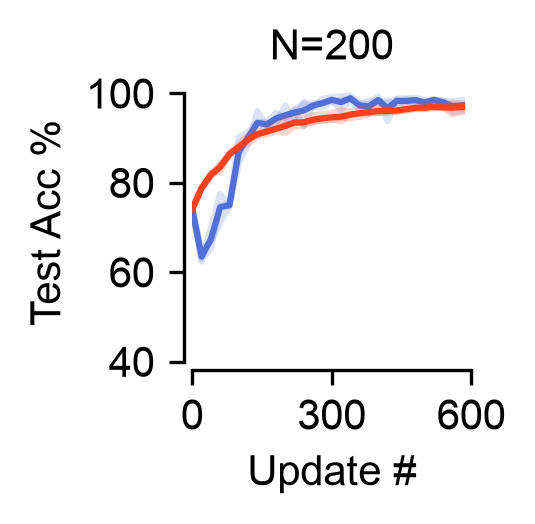

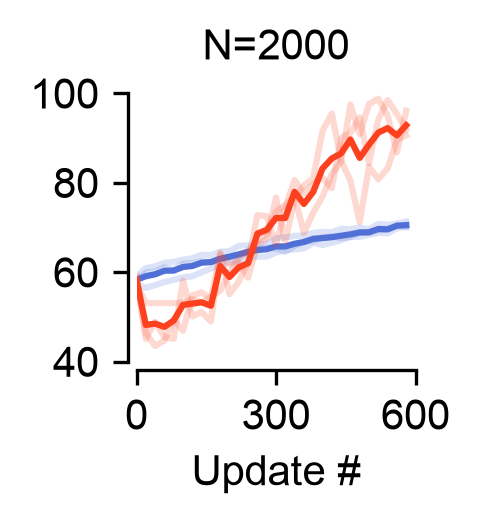

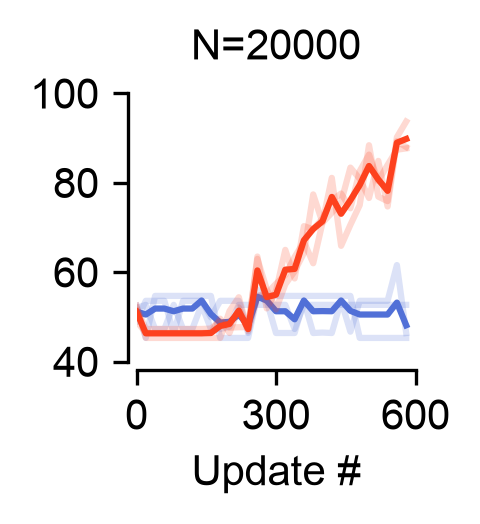

In [29]:
#for nval_key in tasks_dict.keys():
for nval_key in ['n200', 'n2000', 'n20000']:
    best_models = select_first_k_models(tasks_dict[nval_key], k=1)
    title_str = f"N={nval_key.split('n')[-1]}"
    fig = plot_rofk_task(best_models, title_str)  
    fig.savefig(f"fig_rofk_{nval_key[:]}.pdf", bbox_inches="tight", transparent=True)

In [30]:
for nval_key in ['n200', 'n2000', 'n20000']:
    print(nval_key)
    best_models = select_first_k_models(tasks_dict[nval_key], k=1)
    print(best_models["mlp_gd"][0].config['opt'])
    print(best_models["mlp_eg"][0].config['opt'])

n200
{'update_algorithm': 'gd', 'lr': 0.5, 'wd': 0.0, 'momentum': 0}
{'update_algorithm': 'eg', 'lr': 0.75, 'wd': 0.0, 'momentum': 0}
n2000
{'update_algorithm': 'gd', 'lr': 0.01, 'wd': 0.0, 'momentum': 0}
{'update_algorithm': 'eg', 'lr': 1, 'wd': 0.0, 'momentum': 0}
n20000
{'update_algorithm': 'gd', 'lr': 0.01, 'wd': 0.0, 'momentum': 0}
{'update_algorithm': 'eg', 'lr': 1, 'wd': 0.0, 'momentum': 0}
